<a href="https://colab.research.google.com/github/raniyaabubacker884/deep-learning/blob/main/brain_tumor_dl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
! unzip '/content/archive (21) (3).zip'

Archive:  /content/archive (21) (3).zip
  inflating: brain_tumor_dataset/no/1 no.jpeg  
  inflating: brain_tumor_dataset/no/10 no.jpg  
  inflating: brain_tumor_dataset/no/11 no.jpg  
  inflating: brain_tumor_dataset/no/12 no.jpg  
  inflating: brain_tumor_dataset/no/13 no.jpg  
  inflating: brain_tumor_dataset/no/14 no.jpg  
  inflating: brain_tumor_dataset/no/15 no.jpg  
  inflating: brain_tumor_dataset/no/17 no.jpg  
  inflating: brain_tumor_dataset/no/18 no.jpg  
  inflating: brain_tumor_dataset/no/19 no.jpg  
  inflating: brain_tumor_dataset/no/2 no.jpeg  
  inflating: brain_tumor_dataset/no/20 no.jpg  
  inflating: brain_tumor_dataset/no/21 no.jpg  
  inflating: brain_tumor_dataset/no/22 no.jpg  
  inflating: brain_tumor_dataset/no/23 no.jpg  
  inflating: brain_tumor_dataset/no/24 no.jpg  
  inflating: brain_tumor_dataset/no/25 no.jpg  
  inflating: brain_tumor_dataset/no/26 no.jpg  
  inflating: brain_tumor_dataset/no/27 no.jpg  
  inflating: brain_tumor_dataset/no/28 no.jpg  


In [ ]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing import image

In [ ]:
os.listdir("/content")


['.config',
 'archive (21) (3).zip',
 'no',
 'yes',
 'brain_tumor_dataset',
 'sample_data']

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    '/content/brain_tumor_dataset',
    target_size=(128,128),
    batch_size=16,
    class_mode='binary',
    subset='training',
    shuffle=True
)

validation_generator = train_datagen.flow_from_directory(
    '/content/brain_tumor_dataset',
    target_size=(128,128),
    batch_size=16,
    class_mode='binary',
    subset='validation'
)

Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.


In [ ]:
print(train_generator.class_indices)

{'no': 0, 'yes': 1}


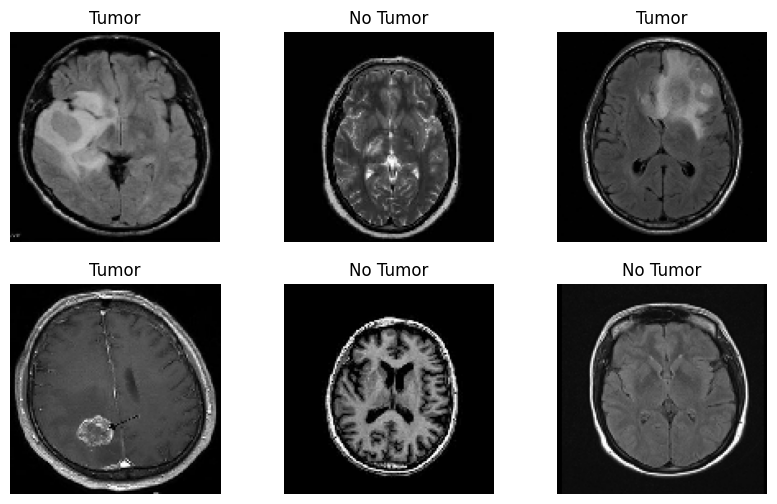

In [ ]:
images, labels = next(train_generator)

plt.figure(figsize=(10,6))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    plt.title("Tumor" if labels[i]==1 else "No Tumor")
    plt.axis("off")

plt.show()

In [ ]:
model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,449 (28.20 MB)

 Trainable params: 7,392,449 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 510ms/step - accuracy: 0.6897 - loss: 0.7582 - val_accuracy: 0.7200 - val_loss: 0.5366
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 383ms/step - accuracy: 0.8030 - loss: 0.4556 - val_accuracy: 0.7800 - val_loss: 0.5113
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 424ms/step - accuracy: 0.8571 - loss: 0.3761 - val_accuracy: 0.7600 - val_loss: 0.4563
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 444ms/step - accuracy: 0.9064 - loss: 0.2523 - val_accuracy: 0.8400 - val_loss: 0.4495
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 385ms/step - accuracy: 0.9163 - loss: 0.2200 - val_accuracy: 0.8000 - val_loss: 0.4850
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 491ms/step - accuracy: 0.9557 - loss: 0.1295 - val_accuracy: 0.9000 - val_loss: 0.3676
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 378ms/step - accuracy: 0.9606 - loss: 0.0952 - val_accuracy: 0.8000 - val_loss: 0.5552
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 468ms/step - accuracy: 0.9901 - loss: 0.0542 - val_accuracy: 0.

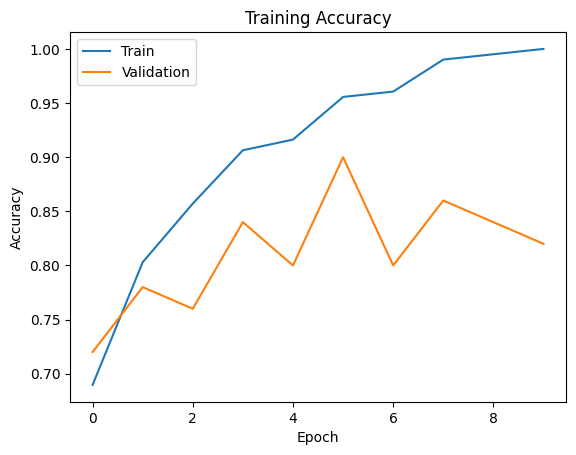

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.show()

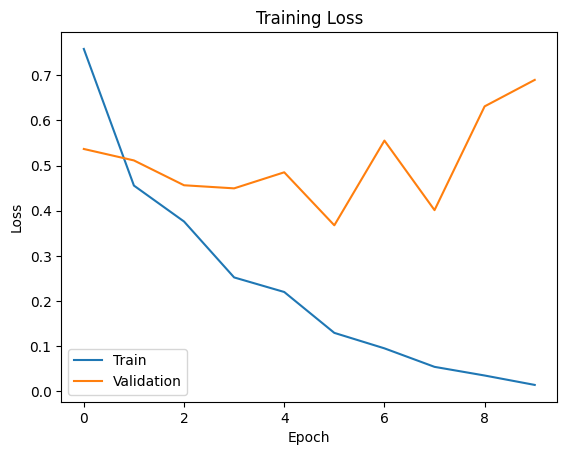

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.show()

In [ ]:
loss, accuracy = model.evaluate(validation_generator)

print("Accuracy:",accuracy*100,"%")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.8200 - loss: 0.6896
Accuracy: 81.99999928474426 %


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import cv2

In [ ]:
import os
import cv2

dataset_path = "/content/brain_tumor_dataset"

X = []
y = []

classes = ["no", "yes"]

for label, folder in enumerate(classes):

    folder_path = os.path.join('/content/brain_tumor_dataset', folder)

    for file in os.listdir(folder_path):

        img = cv2.imread(os.path.join(folder_path, file))
        img = cv2.resize(img, (64, 64))
        img = img.flatten()

        X.append(img)
        y.append(label)

In [ ]:
X=np.array(X)
y=np.array(y)

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
lr=LogisticRegression(max_iter=1000)

lr.fit(X_train,y_train)

prediction=lr.predict(X_test)

print("Logistic Regression Accuracy:",accuracy_score(y_test,prediction))

Logistic Regression Accuracy: 0.803921568627451


In [ ]:
img=image.load_img(
    "/content/images (15).jpg",
    target_size=(128,128)
)

img_array=image.img_to_array(img)

img_array=img_array/255.0

img_array=np.expand_dims(img_array,axis=0)

In [ ]:
prediction=model.predict(img_array)

if prediction[0][0] > 0.5:
    print("Brain Tumor Detected")
else:
    print("No Brain Tumor")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
Brain Tumor Detected


In [ ]:
img=image.load_img(
    "/content/images (9).jpg",
    target_size=(128,128)
)

img_array=image.img_to_array(img)

img_array=img_array/255.0

img_array=np.expand_dims(img_array,axis=0)

In [ ]:
prediction=model.predict(img_array)

if prediction[0][0] > 0.5:
    print("Brain Tumor Detected")
else:
    print("No Brain Tumor")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
No Brain Tumor
